In [1]:
# Cell 1: Cài đặt và Import
!pip install -q torchinfo transformers matplotlib

import os
import json
import shutil
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torchinfo import summary
from tqdm import tqdm

In [2]:
# Cell 2: Cấu hình thư mục
import google.colab.drive
google.colab.drive.mount("/content/drive")

# CHECKPOINT_DIR = "/content/drive/MyDrive/Deep_Learning/VSL_DL/CSLR_Checkpoints"
CHECKPOINT_DIR = "/content/CSLR_Checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
LATEST_CKPT = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")
BEST_CKPT   = os.path.join(CHECKPOINT_DIR, "best_model.pth")


Mounted at /content/drive


In [3]:
# Cell 3: Giải nén dataset từ Google Drive
ZIP_ON_DRIVE   = "/content/drive/MyDrive/Deep_Learning/VSL_DL/cslr_dataset_2.zip"
EXTRACT_DIR    = "/content/processed_data"

if not os.path.exists(os.path.join(EXTRACT_DIR, "features")):
    print("Đang giải nén dataset...")
    shutil.unpack_archive(ZIP_ON_DRIVE, EXTRACT_DIR)
    print("Giải nén xong!")

Đang giải nén dataset...
Giải nén xong!


In [4]:
# Cell 4: Cấu hình chung (TỐI ƯU CHO DỮ LIỆU NHỎ)
with open(os.path.join(EXTRACT_DIR, "label_mapping.json"), "r", encoding="utf-8") as f:
    label_map = json.load(f)
    idx_to_label = {v: k for k, v in label_map.items()}

NUM_CLASSES  = len(label_map)
SEQ_LEN      = 60
NUM_JOINTS   = 67
IN_CHANNELS  = 9

HIDDEN_DIM       = 256
NUM_GCN_LAYERS   = 3
NUM_ATTN_HEADS   = 4
NUM_TRANS_LAYERS = 2
DROPOUT          = 0.3          # Tăng lên 0.5 để bắt các nơ-ron tự thích nghi độc lập, chống học vẹt

BATCH_SIZE   = 32            # Giảm xuống 8 cho dữ liệu nhỏ để tối ưu hóa gradient
NUM_EPOCHS   = 80           # Hạ tổng số epoch tối đa xuống 80
MAX_LR       = 1e-3         # Đồng bộ nhất quán mức LR tối đa với OneCycleLR
WEIGHT_DECAY = 1e-4         # Tăng L2 Regularization chống Overfitting

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Tổng số từ vựng (NUM_CLASSES) : {NUM_CLASSES}")
print(f"Đang chạy trên thiết bị       : {DEVICE}")


Tổng số từ vựng (NUM_CLASSES) : 538
Đang chạy trên thiết bị       : cuda


In [5]:
# Cell 5: Dataset & DataLoader (Bổ sung Spatial Augmentation)
class SignLanguageDataset(Dataset):
    def __init__(self, csv_path: str, root_dir: str, is_train: bool = False):
        self.df = pd.read_csv(csv_path)
        self.root_dir = root_dir
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.root_dir, str(row["path"]).replace("\\", "/"))

        # Load dữ liệu dạng: (SEQ_LEN, NUM_JOINTS, IN_CHANNELS)
        data = np.load(file_path)["sequence"]
        data = data.reshape(SEQ_LEN, NUM_JOINTS, IN_CHANNELS)
        data = np.nan_to_num(data, nan=0.0)

        # --- SOTA SPATIAL AUGMENTATION ---
        # Chỉ áp dụng Data Augmentation cho tập Train
        if self.is_train:

            # 1. Random Scaling (Thu phóng)
            # Mô phỏng việc người biểu diễn đứng xa hoặc gần camera hơn
            if random.random() < 0.5:
                scale_factor = np.random.uniform(0.8, 1.2)
                # Giả định Kênh 0 và 1 là tọa độ X, Y. Phóng to/thu nhỏ khung xương.
                data[:, :, :2] *= scale_factor

            # 2. Random Translation (Dịch chuyển Không gian)
            # Mô phỏng việc người biểu diễn không đứng ngay chính giữa khung hình
            if random.random() < 0.5:
                shift_x = np.random.uniform(-0.05, 0.05)
                shift_y = np.random.uniform(-0.05, 0.05)
                data[:, :, 0] += shift_x  # Dịch toàn bộ khớp theo trục X
                data[:, :, 1] += shift_y  # Dịch toàn bộ khớp theo trục Y

            # 3. Jittering (Nhiễu Gaussian)
            # Mô phỏng các sai số nội tại của thuật toán trích xuất MediaPipe
            if random.random() < 0.5:
                noise = np.random.normal(0, 0.002, data.shape)
                data += noise

        # Đổi chiều dữ liệu sang chuẩn đầu vào của PyTorch (C, T, V)
        data = np.transpose(data, (2, 0, 1))
        tensor_data = torch.from_numpy(data).float()
        label       = int(row["label"])

        return tensor_data, label

def collate_fn(batch):
    inputs = torch.stack([item[0] for item in batch])
    targets = torch.tensor([item[1] for item in batch], dtype=torch.long)
    return inputs, targets

# Khởi tạo DataLoader
train_loader = DataLoader(
    SignLanguageDataset(os.path.join(EXTRACT_DIR, "train.csv"), EXTRACT_DIR, is_train=True),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collate_fn,
    num_workers=2, pin_memory=True # Tối ưu hóa việc đẩy dữ liệu lên GPU
)

val_loader = DataLoader(
    SignLanguageDataset(os.path.join(EXTRACT_DIR, "val.csv"), EXTRACT_DIR, is_train=False),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
    num_workers=2, pin_memory=True
)

print(f"Khởi tạo Loader thành công! Đã kích hoạt Spatial Augmentation cho tập Train.")

Khởi tạo Loader thành công! Đã kích hoạt Spatial Augmentation cho tập Train.


In [6]:
# Cell 6: Ma trận kề (Adjacency Matrix)
def build_adjacency(num_joints: int = 67) -> torch.Tensor:
    A = np.zeros((num_joints, num_joints), dtype=np.float32)
    def connect(i, j):
        A[i, j] = A[j, i] = 1

    pose_edges = [(0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),(9,10),(11,12),(11,13),(13,15),(12,14),(14,16),(11,23),(12,24),(23,24),(0,11),(0,12)]
    for i, j in pose_edges:
        if i < 25 and j < 25: connect(i, j)

    hand_edges = [(0,1),(1,2),(2,3),(3,4),(0,5),(5,6),(6,7),(7,8),(0,9),(9,10),(10,11),(11,12),(0,13),(13,14),(14,15),(15,16),(0,17),(17,18),(18,19),(19,20),(5,9),(9,13),(13,17)]
    for i, j in hand_edges: connect(25 + i, 25 + j) # Tay trái
    for i, j in hand_edges: connect(46 + i, 46 + j) # Tay phải

    connect(15, 25) # Cổ tay trái -> Gốc bàn tay trái
    connect(16, 46) # Cổ tay phải -> Gốc bàn tay phải
    np.fill_diagonal(A, 1)

    D_inv = np.diag(1.0 / np.maximum(A.sum(axis=1), 1e-6) ** 0.5)
    A_hat = D_inv @ A @ D_inv
    return torch.from_numpy(A_hat).float()

ADJ = build_adjacency(NUM_JOINTS).to(DEVICE)

In [7]:
# Cell 7: Các Lớp Khối (GCN & Positional Encoding)
class GraphConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.W    = nn.Linear(in_ch, out_ch, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_ch))
        self.bn   = nn.BatchNorm2d(out_ch)
        self.act  = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor, A: torch.Tensor) -> torch.Tensor:
        out = self.W(x)
        out = torch.einsum("btvc,vw->btwc", out, A) + self.bias
        out = out.permute(0, 3, 1, 2)
        out = self.act(self.bn(out))
        return out.permute(0, 2, 3, 1)

class STGCNBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, dropout: float = 0.1):
        super().__init__()
        self.gcn = GraphConv(in_ch, out_ch)
        self.tcn = nn.Sequential(
            nn.Conv2d(out_ch, out_ch, kernel_size=(3, 1), padding=(1, 0), groups=out_ch),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.residual = nn.Sequential(nn.Conv2d(in_ch, out_ch, 1), nn.BatchNorm2d(out_ch)) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, A: torch.Tensor) -> torch.Tensor:
        res = x.permute(0, 3, 1, 2)
        out = self.gcn(x, A).permute(0, 3, 1, 2)
        out = self.tcn(out) + self.residual(res)
        return out.permute(0, 2, 3, 1)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(1, max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

In [8]:
# Cell 8: Mô hình Chính VSTGCN (SOTA SPATIAL PROJECTION)
class VSTGCN(nn.Module):
    def __init__(self, in_ch=IN_CHANNELS, num_joints=NUM_JOINTS, hidden_dim=HIDDEN_DIM,
                 num_gcn=NUM_GCN_LAYERS, num_heads=NUM_ATTN_HEADS, num_trans=NUM_TRANS_LAYERS,
                 output_size=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()

        # Khởi tạo danh sách số kênh cho GCN
        gcn_channels = [in_ch] + [hidden_dim] * num_gcn
        self.stgcn = nn.ModuleList([
            STGCNBlock(gcn_channels[i], gcn_channels[i + 1], dropout) for i in range(num_gcn)
        ])

        self.pos_encoder = PositionalEncoding(hidden_dim, max_len=SEQ_LEN)

        # Transformer Encoder
        enc_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_trans)

        # NÂNG CẤP SOTA: Trải phẳng (Flatten) thay vì Mean Pooling.
        # Nhận đầu vào là (V * C) để bảo toàn từng điểm khớp, sau đó nén lại về hidden_dim
        self.spatial_proj = nn.Sequential(
            nn.Linear(num_joints * hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim)
        )

        self.fc = nn.Linear(hidden_dim, output_size)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor, A: torch.Tensor) -> torch.Tensor:
        # x shape ban đầu: (B, C, T, V) -> Đổi thành (B, T, V, C) để đưa vào STGCN
        x = x.permute(0, 2, 3, 1)

        # Đi qua các khối GCN để học đặc trưng không gian
        for block in self.stgcn:
            x = block(x, A)

        # BẢO TOÀN KHÔNG GIAN KHỚP (Fix lỗi Overfitting)
        B, T, V, C = x.shape

        # Trải phẳng chiều Không gian (V) và chiều Đặc trưng (C) thành 1 vector dài
        # Shape từ (B, T, V, C) -> (B, T, V * C)
        x = x.reshape(B, T, V * C)

        # Chiếu vector dài đó về lại kích thước hidden_dim để đưa vào Transformer
        # Shape: (B, T, hidden_dim)
        x = self.spatial_proj(x)

        # Đưa vào Transformer để học chuỗi thời gian
        x = self.pos_encoder(x)
        x = self.transformer(x)

        # Gom cụm theo chiều thời gian để đưa ra quyết định cuối cùng
        x = x.mean(dim=1) # (B, hidden_dim)

        logits = self.fc(x)
        return logits

# Kiểm tra lại kiến trúc mô hình
model = VSTGCN().to(DEVICE)
print(summary(model, input_data=(torch.zeros(2, IN_CHANNELS, SEQ_LEN, NUM_JOINTS).to(DEVICE), ADJ), verbose=0))

/tmp/ipykernel_903/3598346007.py:21: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_trans)


Layer (type:depth-idx)                        Output Shape              Param #
VSTGCN                                        [2, 538]                  --
├─ModuleList: 1-1                             --                        --
│    └─STGCNBlock: 2-1                        [2, 60, 67, 256]          --
│    │    └─GraphConv: 3-1                    [2, 60, 67, 256]          3,072
│    │    └─Sequential: 3-2                   [2, 256, 60, 67]          1,536
│    │    └─Sequential: 3-3                   [2, 256, 60, 67]          3,072
│    └─STGCNBlock: 2-2                        [2, 60, 67, 256]          --
│    │    └─GraphConv: 3-4                    [2, 60, 67, 256]          66,304
│    │    └─Sequential: 3-5                   [2, 256, 60, 67]          1,536
│    │    └─Identity: 3-6                     [2, 256, 60, 67]          --
│    └─STGCNBlock: 2-3                        [2, 60, 67, 256]          --
│    │    └─GraphConv: 3-7                    [2, 60, 67, 256]          66,304


In [9]:
# Cell 9: Loss, Optimizer & Scheduler
# Cross Entropy tích hợp Label Smoothing chống Overfitting
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = AdamW(model.parameters(), lr=MAX_LR, weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=MAX_LR,         # Đã sửa đồng bộ nhất quán với MAX_LR từ cấu hình (5e-4)
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.3,         # Dành 30% epoch đầu để tăng dần LR (warm-up)
    div_factor=25.0,
    final_div_factor=1000.0
)

In [10]:
# Cell 10: Auto-Resume Checkpoint (Version An Toàn)
start_epoch = 0
best_val_loss = float("inf")

# Khởi tạo bộ lưu lịch sử train
history = {
    "train_loss": [], "val_loss": [],
    "val_top1": [], "val_top5": []
}

if os.path.exists(LATEST_CKPT):
    print(f"Đang tìm thấy checkpoint tại: {LATEST_CKPT}")
    try:
        ckpt = torch.load(LATEST_CKPT, map_location=DEVICE)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])
        start_epoch   = ckpt["epoch"] + 1
        best_val_loss = ckpt.get("best_val_loss", float("inf"))
        if "history" in ckpt:
            history = ckpt["history"]
        print(f"  → Khôi phục thành công! Tiếp tục từ epoch {start_epoch}")
    except RuntimeError as e:
        print("\n[CẢNH BÁO] Kiến trúc mô hình đã thay đổi so với Checkpoint cũ!")
        print("Tiến hành khởi tạo lại trọng số và huấn luyện từ Epoch 0...\n")
        # Reset lại lịch sử
        start_epoch = 0
        best_val_loss = float("inf")
else:
    print("Không tìm thấy checkpoint. Bắt đầu training từ đầu.")

Không tìm thấy checkpoint. Bắt đầu training từ đầu.


In [11]:
# Cell 11: Hàm Chạy & Đánh Giá (Train / Val có Mixup)
def run_epoch(loader, is_train: bool):
    model.train() if is_train else model.eval()
    total_loss, n_batches = 0.0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()

    with ctx:
        pbar = tqdm(loader, desc="  Train", leave=False) if is_train else loader
        for inputs, targets in pbar:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

            # Thêm SOTA Mixup Augmentation ngay trên feature sequences giúp làm mượt không gian đặc trưng quyết định
            if is_train and random.random() < 0.5:
                alpha = 0.3
                lam = np.random.beta(alpha, alpha)
                rand_index = torch.randperm(inputs.size(0)).to(DEVICE)

                inputs_b = inputs[rand_index]
                targets_a = targets
                targets_b = targets[rand_index]

                logits = model(inputs * lam + inputs_b * (1.0 - lam), ADJ)
                loss = lam * criterion(logits, targets_a) + (1.0 - lam) * criterion(logits, targets_b)
            else:
                logits = model(inputs, ADJ)
                loss = criterion(logits, targets)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Chống nổ gradient do batch nhỏ
                optimizer.step()
                scheduler.step()

            total_loss += loss.item()
            n_batches  += 1
            if is_train:
                pbar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / max(n_batches, 1)

def evaluate(loader):
    model.eval()
    total_loss, n_batches = 0.0, 0
    n_correct_top1, n_correct_top5, n_total = 0, 0, 0

    with torch.no_grad():
        for inputs, targets in tqdm(loader, desc="  Val  ", leave=False):
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

            logits = model(inputs, ADJ)
            loss = criterion(logits, targets)
            total_loss += loss.item()
            n_batches += 1

            # Top-1 Acc
            _, preds = torch.max(logits, 1)
            n_correct_top1 += (preds == targets).sum().item()

            # Top-5 Acc
            _, top5_preds = logits.topk(5, dim=1)
            targets_expanded = targets.view(-1, 1).expand_as(top5_preds)
            n_correct_top5 += (top5_preds == targets_expanded).sum().item()

            n_total += inputs.size(0)

    return {
        "val_loss": total_loss / max(n_batches, 1),
        "top1_acc": n_correct_top1 / max(n_total, 1) * 100,
        "top5_acc": n_correct_top5 / max(n_total, 1) * 100,
    }


In [12]:
# Cell 12: Định nghĩa Class Early Stopping (SỬA PATIENCE LÊN 12)
class EarlyStopping:
    def __init__(self, patience=14, min_delta=1e-4):
        """
        patience: Tăng lên 12 để tránh dừng sớm oan uổng do biến động của tập val rất nhỏ.
        min_delta: Mức cải thiện tối thiểu yêu cầu.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'   [EarlyStopping] Cảnh báo: val_loss không giảm. Bộ đếm: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [13]:
# Cell 13: Vòng lặp Huấn luyện chính
print(f"\nBắt đầu training từ epoch {start_epoch} → {NUM_EPOCHS - 1}")

early_stopper = EarlyStopping(patience=12, min_delta=1e-4) # Sử dụng patience = 12

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"Epoch [{epoch + 1:>3}/{NUM_EPOCHS}]")

    train_loss = run_epoch(train_loader, is_train=True)
    metrics    = evaluate(val_loader)
    val_loss   = metrics["val_loss"]
    top1_acc   = metrics["top1_acc"]
    top5_acc   = metrics["top5_acc"]

    # Lưu lại lịch sử epoch phục vụ vẽ biểu đồ
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_top1"].append(top1_acc)
    history["val_top5"].append(top5_acc)

    print(
        f"  train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"top1={top1_acc:.1f}% | top5={top5_acc:.1f}% | "
        f"lr={scheduler.get_last_lr()[0]:.2e}"
    )

    ckpt = {
        "epoch"         : epoch,
        "model"         : model.state_dict(),
        "optimizer"     : optimizer.state_dict(),
        "scheduler"     : scheduler.state_dict(),
        "best_val_loss" : best_val_loss,
        "train_loss"    : train_loss,
        "val_loss"      : val_loss,
        "top1_acc"      : top1_acc,
        "top5_acc"      : top5_acc,
        "history"       : history # Đóng gói luôn lịch sử học tập vào checkpoint
    }
    torch.save(ckpt, LATEST_CKPT)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        shutil.copy(LATEST_CKPT, BEST_CKPT)
        print(f"  ★ Đã lưu best_model (val_loss={best_val_loss:.4f}, top1={top1_acc:.1f}%)")

    # Gọi Early Stopping
    early_stopper(val_loss)
    if early_stopper.early_stop:
        print(f"\n🛑 KÍCH HOẠT EARLY STOPPING! Mô hình không còn cải thiện sau {early_stopper.patience} Epochs.")
        print(f"Tiến trình dừng sớm tại Epoch {epoch+1}. Model tốt nhất đã được lưu ở best_model.pth")
        break

print("\nTraining hoàn tất!")


Bắt đầu training từ epoch 0 → 79
Epoch [  1/80]


  train_loss=5.7383 | val_loss=5.2436 | top1=4.9% | top5=14.8% | lr=4.41e-05
  ★ Đã lưu best_model (val_loss=5.2436, top1=4.9%)
Epoch [  2/80]


  train_loss=4.8653 | val_loss=4.7181 | top1=12.0% | top5=26.6% | lr=5.64e-05
  ★ Đã lưu best_model (val_loss=4.7181, top1=12.0%)
Epoch [  3/80]


  train_loss=4.1317 | val_loss=4.1792 | top1=19.3% | top5=43.9% | lr=7.65e-05
  ★ Đã lưu best_model (val_loss=4.1792, top1=19.3%)
Epoch [  4/80]


  train_loss=3.3744 | val_loss=3.6988 | top1=31.0% | top5=57.7% | lr=1.04e-04
  ★ Đã lưu best_model (val_loss=3.6988, top1=31.0%)
Epoch [  5/80]


...

  train_loss=0.8539 | val_loss=1.6109 | top1=79.0% | top5=87.2% | lr=1.26e-05
  ★ Đã lưu best_model (val_loss=1.6109, top1=79.0%)
Epoch [ 77/80]


  train_loss=0.8469 | val_loss=1.6114 | top1=79.2% | top5=86.9% | lr=7.10e-06
   [EarlyStopping] Cảnh báo: val_loss không giảm. Bộ đếm: 1/12
Epoch [ 78/80]


  train_loss=0.8508 | val_loss=1.6152 | top1=79.0% | top5=87.0% | lr=3.18e-06
   [EarlyStopping] Cảnh báo: val_loss không giảm. Bộ đếm: 2/12
Epoch [ 79/80]


  train_loss=0.8669 | val_loss=1.6151 | top1=79.3% | top5=87.2% | lr=8.24e-07
   [EarlyStopping] Cảnh báo: val_loss không giảm. Bộ đếm: 3/12
Epoch [ 80/80]


  train_loss=0.8788 | val_loss=1.6118 | top1=79.2% | top5=86.8% | lr=4.00e-08
   [EarlyStopping] Cảnh báo: val_loss không giảm. Bộ đếm: 4/12

Training hoàn tất!


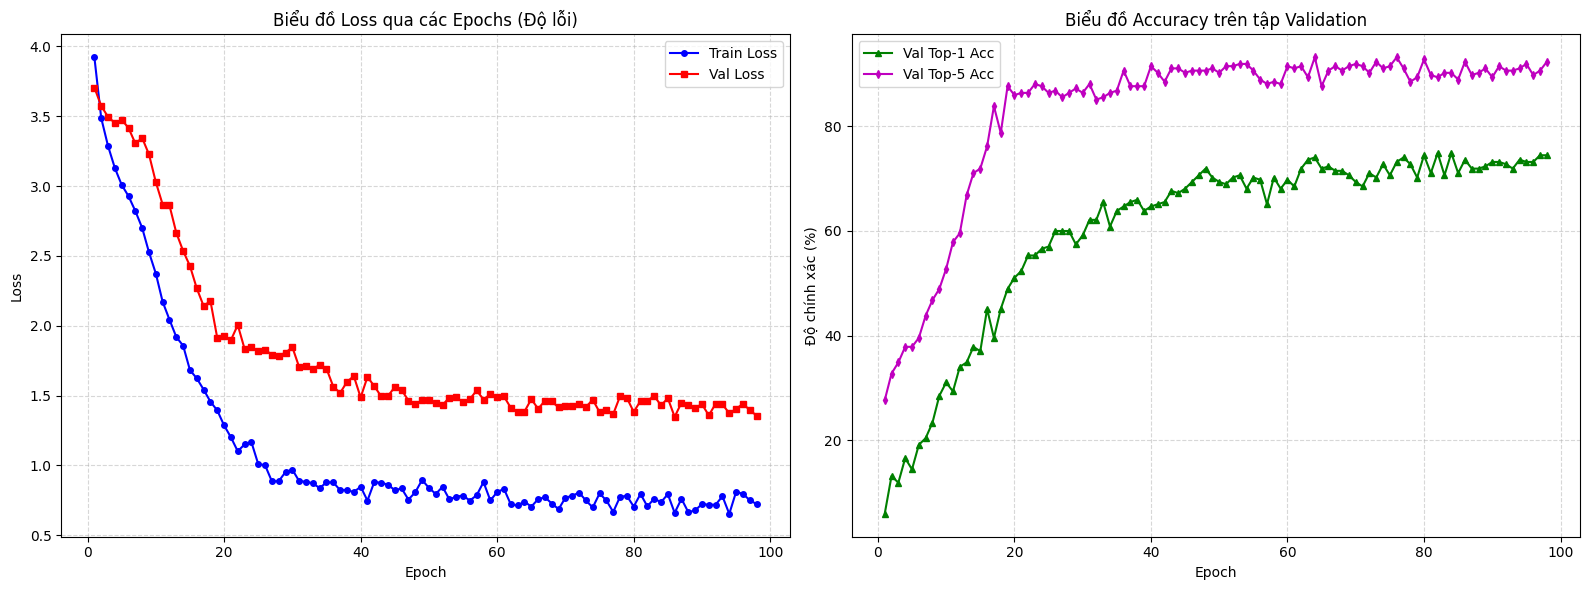

In [ ]:
# Cell 14: Vẽ biểu đồ đánh giá mô hình (Loss & Accuracy)
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(16, 6))

# 1. Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], 'b-o', label='Train Loss', markersize=4)
plt.plot(epochs_range, history["val_loss"], 'r-s', label='Val Loss', markersize=4)
plt.title('Biểu đồ Loss qua các Epochs (Độ lỗi)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Biểu đồ Accuracy (Độ chính xác)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["val_top1"], 'g-^', label='Val Top-1 Acc', markersize=4)
plt.plot(epochs_range, history["val_top5"], 'm-d', label='Val Top-5 Acc', markersize=4)
plt.title('Biểu đồ Accuracy trên tập Validation')
plt.xlabel('Epoch')
plt.ylabel('Độ chính xác (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
